# 🎓 LinguaLoop(말문) **v2** — 핵심 기능 추가 (AI Language Learning Partner)

> 코어 흐름 `표현 추출 → 🔧 Tool 보강 → 퀴즈 → 채점 → (사용자 선택) 역할극 / 플래시카드 → 피드백 → 복습` 을 LangGraph로 구현.


In [ ]:
import os
import json
import operator
from typing import TypedDict, Annotated, List, Dict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver         
from langchain_core.messages import (
    HumanMessage, AIMessage, SystemMessage, BaseMessage,
)
from langchain_core.tools import tool                       

USE_REAL_LLM = bool(os.getenv("OPENAI_API_KEY"))
_llm = None
if USE_REAL_LLM:
    from langchain_openai import ChatOpenAI
    _llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)

print("모드:", "실제 GPT 호출" if USE_REAL_LLM else "mock 응답 (오프라인 데모)")


def llm_json(system, user, mock):
    if not USE_REAL_LLM:
        return mock
    r = _llm.invoke([SystemMessage(content=system), HumanMessage(content=user)])
    t = r.content.strip().strip("`")
    if t.lower().startswith("json"):
        t = t[4:]
    return json.loads(t)


def llm_text(messages, mock):
    if not USE_REAL_LLM:
        return mock
    return _llm.invoke(messages).content

모드: 실제 GPT 호출


## 0-1. 샘플 입력 & mock 데이터

In [ ]:
# 예시 자막 (실제로는 YouTube Data API / Whisper로 수집)
SAMPLE_TRANSCRIPT = """
Hi there! Welcome. What can I get for you today?
I'll have a medium latte, please.
Sure. Would you like it hot or iced?
Iced, please. Could you make it less sweet?
Of course. Is that for here or to go?
To go, thanks. Anything else?
No, that's all.
Okay, that comes to four fifty. Have a great day!
"""

MOCK_EXPRESSIONS = [
    {"expression": "I'll have ...",         "meaning": "~로 할게요 (주문)",     "example": "I'll have a medium latte, please."},
    {"expression": "Could you make it ...?","meaning": "~하게 해주실 수 있나요?", "example": "Could you make it less sweet?"},
    {"expression": "for here or to go",     "meaning": "매장/포장 여부",        "example": "Is that for here or to go?"},
    {"expression": "Anything else?",        "meaning": "더 필요하신 거 있나요?", "example": "No, that's all."},
    {"expression": "that comes to ...",     "meaning": "합계가 ~입니다",        "example": "That comes to four fifty."},
]

MOCK_QUIZ = [
    {"question": "주문할 때: '___ a medium latte, please.'", "answer": "I'll have"},
    {"question": "덜 달게: 'Could you ___ it less sweet?'",  "answer": "make"},
    {"question": "포장 확인: 'Is that for here or ___?'",     "answer": "to go"},
]

# 역할극에서 파트너(바리스타)의 mock 대사
MOCK_PARTNER_REPLIES = [
    "Sure! Would you like it hot or iced?",
    "One iced latte coming up. For here or to go?",
    "Great — that comes to four fifty. Anything else?",
]

# 데모용 가상 학습자 발화 (실제 서비스에서는 UI 사용자 입력으로 대체)
SIMULATED_LEARNER = [
    "Hi, I'll have a latte, please.",
    "Could you make it iced?",
    "To go, thanks.",
]

## 1. 🔧 Tool 연동

`@tool` 데코레이터로 **Tool 2개**를 정의합니다.
- `dictionary_lookup` — 표현의 간단한 정의와 유의어 반환
- `example_sentence_search` — **웹 검색(DuckDuckGo)** 으로 표현의 실제 사용 예문을 가져옴

두 Tool은 아래 `enrich_expressions` 노드에서 호출됩니다.

In [ ]:
# 웹 검색 사용 여부 (True면 실제 DuckDuckGo 검색, False면 대체 예문)
USE_WEB_SEARCH = True

# 오프라인/검색 실패 시 대체 예문
_FALLBACK_EXAMPLES = {
    "I'll have ...":         "I'll have the soup of the day.",
    "Could you make it ...?":"Could you make it decaf, please?",
    "for here or to go":     "Is that for here or to go?",
    "Anything else?":        "Anything else for you today?",
    "that comes to ...":     "That comes to twelve dollars.",
}


@tool
def dictionary_lookup(expression: str) -> dict:
    """영어 표현의 간단한 정의와 유의어(최대 2개)를 반환한다."""
    KB = {
        "I'll have ...":         {"definition": "used to place an order",     "synonyms": ["I'd like", "Can I get"]},
        "Could you make it ...?":{"definition": "politely request a change",  "synonyms": ["Can you make it", "Would you make it"]},
        "for here or to go":     {"definition": "dine-in or takeout",         "synonyms": ["eat in or take out"]},
        "Anything else?":        {"definition": "asking if more is needed",   "synonyms": ["Is that all?", "Will that be all?"]},
        "that comes to ...":     {"definition": "stating the total price",    "synonyms": ["the total is", "that'll be"]},
    }
    return KB.get(expression, {"definition": "(no entry)", "synonyms": []})


@tool
def example_sentence_search(expression: str) -> list:
    """웹(DuckDuckGo)에서 표현의 실제 사용 예문을 검색한다."""
    if USE_WEB_SEARCH:
        try:
            from langchain_community.tools import DuckDuckGoSearchRun
            query = f'"{expression}" example sentence English'
            text = DuckDuckGoSearchRun().invoke(query)
            # 검색 결과 텍스트를 문장 단위로 잘라 앞쪽 1-2개를 예문 후보로 사용
            parts = [p.strip() for p in text.replace("\n", " ").split(". ") if p.strip()]
            if parts:
                return [(p if p.endswith(".") else p + ".") for p in parts[:2]]
        except Exception as e:
            print(f"[web search fallback] {expression}: {e}")
    # 폴백 (오프라인/실패/USE_WEB_SEARCH=False)
    return [_FALLBACK_EXAMPLES.get(expression, f"Example using '{expression}'.")]


TOOLS = [dictionary_lookup, example_sentence_search]

등록된 tool: dictionary_lookup, example_sentence_search


## 2. State 정의

추가된 필드: `enriched_expressions`(Tool 결과), `quiz_answers`/`quiz_score`(채점),
`practice_mode`(사용자 선택 — 분기 기준), `flashcards`(대체 경로 산출물),
`study_history`(메모리 — `operator.add` 리듀서로 누적).

- `messages` 는 `add_messages`, `study_history` 는 `operator.add` 리듀서로 값이 **누적**됩니다.
- `TypedDict` 이므로 노드 안에서는 `state["key"]` 형태로 접근합니다.

In [4]:
class LearningState(TypedDict):
    native_language: str
    target_language: str
    transcript: str
    key_expressions: List[Dict]
    enriched_expressions: List[Dict]                    # 🔧 Tool 결과
    quiz: List[Dict]
    quiz_answers: List[str]                             # 사용자 퀴즈 답
    quiz_score: int
    practice_mode: str                                 # 사용자 입력 → 분기 기준
    messages: Annotated[list, add_messages]
    turn_count: int
    max_turns: int
    feedback: str
    review_list: List[Dict]
    flashcards: List[Dict]                             # 대체 경로 산출물
    study_history: Annotated[list, operator.add]       # 💾 메모리
    stage: str

## 3. 노드 구현 (8개)

In [5]:
# ① 표현 추출
def extract_expressions(state: LearningState) -> dict:
    system = ("You are a language coach. Extract 5-10 conversational expressions. "
              'Return JSON list of {"expression","meaning","example"}.')
    user = f"Target: {state['target_language']}\nTranscript:\n{state['transcript']}"
    return {"key_expressions": llm_json(system, user, mock=MOCK_EXPRESSIONS), "stage": "enrich"}


# ② 🔧 Tool 보강 (Tool 연동 노드)
def enrich_expressions(state: LearningState) -> dict:
    enriched = []
    for e in state["key_expressions"]:
        d = dictionary_lookup.invoke({"expression": e["expression"]})
        ex = example_sentence_search.invoke({"expression": e["expression"]})
        enriched.append({**e,
                         "definition": d["definition"],
                         "synonyms": d["synonyms"],
                         "extra_examples": ex})
    return {"enriched_expressions": enriched,
            "study_history": [f"🔧 enriched {len(enriched)} expressions"],
            "stage": "quiz"}


# ③ 퀴즈 생성
def generate_quiz(state: LearningState) -> dict:
    system = 'Make a 3-item fill-in-the-blank quiz. Return JSON list of {"question","answer"}.'
    user = json.dumps(state["enriched_expressions"], ensure_ascii=False)
    return {"quiz": llm_json(system, user, mock=MOCK_QUIZ), "stage": "grade"}


# ④ 퀴즈 채점
def grade_quiz(state: LearningState) -> dict:
    score = sum(
        1 for q, a in zip(state["quiz"], state["quiz_answers"])
        if a.strip().lower() == q["answer"].strip().lower()
    )
    return {"quiz_score": score,
            "study_history": [f"📝 quiz score {score}/{len(state['quiz'])}"],
            "stage": "choose"}


# ⑤ 역할극 대화 파트너 (조건부 자기 순환)
def roleplay_partner(state: LearningState) -> dict:
    turn = state["turn_count"]
    learner_utt = SIMULATED_LEARNER[turn] if turn < len(SIMULATED_LEARNER) else "Thanks, bye!"
    targets = ", ".join(e["expression"] for e in state["key_expressions"])
    system = SystemMessage(content=(
        "You are a friendly barista. Roleplay a short cafe chat and encourage the "
        f"learner to use: {targets}. Keep replies to 1-2 sentences."))
    convo = [system] + list(state["messages"]) + [HumanMessage(content=learner_utt)]
    reply = llm_text(convo, mock=MOCK_PARTNER_REPLIES[min(turn, len(MOCK_PARTNER_REPLIES) - 1)])
    return {"messages": [HumanMessage(content=learner_utt), AIMessage(content=reply)],
            "turn_count": turn + 1, "stage": "roleplay"}


def route_after_roleplay(state: LearningState) -> str:
    return "give_feedback" if state["turn_count"] >= state["max_turns"] else "roleplay_partner"


# ⑥ 피드백
def give_feedback(state: LearningState) -> dict:
    learner_text = " ".join(m.content for m in state["messages"]
                            if isinstance(m, HumanMessage)).lower()
    used, missed = [], []
    for e in state["key_expressions"]:
        head = e["expression"].split(" ...")[0].split(" or ")[0].strip().lower()
        (used if head and head in learner_text else missed).append(e)
    lines = [f"✅ 사용한 표현 {len(used)}개 / ❌ 미사용 {len(missed)}개"]
    if used:
        lines.append("잘 쓴 표현: " + ", ".join(e["expression"] for e in used))
    if missed:
        lines.append("다음엔 이 표현도 써보세요: " + ", ".join(e["expression"] for e in missed))
    return {"feedback": "\n".join(lines), "review_list": missed,
            "study_history": [f"✅ used: {e['expression']}" for e in used],
            "stage": "review"}


# ⑦ 복습 리스트
def build_review(state: LearningState) -> dict:
    review = [{"expression": e["expression"], "meaning": e["meaning"],
               "example": e["example"], "review_after_days": [1, 3, 7][i % 3]}
              for i, e in enumerate(state["review_list"])]
    return {"review_list": review,
            "study_history": [f"🔁 review scheduled: {len(review)} expressions"],
            "stage": "done"}


# ⑤' 플래시카드 (대체 경로)
def build_flashcards(state: LearningState) -> dict:
    src = state["enriched_expressions"] or state["key_expressions"]
    cards = [{"front": e["expression"], "back": e["meaning"], "example": e["example"]}
             for e in src]
    return {"flashcards": cards,
            "study_history": [f"🃏 built {len(cards)} flashcards"],
            "stage": "done"}

## 4. Conditional Edge — 사용자 입력에 따른 분기

`grade_quiz` 다음에서 **사용자가 고른 연습 방식(`practice_mode`)** 에 따라 경로가 갈립니다.
- `"roleplay"` → `roleplay_partner` (역할극 대화 → 피드백 → 복습)
- `"flashcards"` → `build_flashcards` (플래시카드 생성)

In [6]:
def route_by_mode(state: LearningState) -> str:
    # 사용자 입력(practice_mode)에 따라 다른 노드로 라우팅
    if state["practice_mode"] == "flashcards":
        return "build_flashcards"
    return "roleplay_partner"

## 5. 그래프 연결 & compile (+ SQLite 메모리)

`SqliteSaver` checkpointer를 붙여 **SQLite 파일(`lingualoop_memory.sqlite`)** 에 `thread_id` 별 상태가 저장됩니다.

In [7]:
builder = StateGraph(LearningState)
for name, fn in [
    ("extract_expressions", extract_expressions),
    ("enrich_expressions", enrich_expressions),
    ("generate_quiz", generate_quiz),
    ("grade_quiz", grade_quiz),
    ("roleplay_partner", roleplay_partner),
    ("give_feedback", give_feedback),
    ("build_review", build_review),
    ("build_flashcards", build_flashcards),
]:
    builder.add_node(name, fn)

builder.add_edge(START, "extract_expressions")
builder.add_edge("extract_expressions", "enrich_expressions")
builder.add_edge("enrich_expressions", "generate_quiz")
builder.add_edge("generate_quiz", "grade_quiz")

# ── Conditional Edge #1: 사용자 입력 기반 분기 ──
builder.add_conditional_edges("grade_quiz", route_by_mode,
    {"roleplay_partner": "roleplay_partner", "build_flashcards": "build_flashcards"})

# ── Conditional Edge #2: 역할극 반복 루프 ──
builder.add_conditional_edges("roleplay_partner", route_after_roleplay,
    {"roleplay_partner": "roleplay_partner", "give_feedback": "give_feedback"})

builder.add_edge("give_feedback", "build_review")
builder.add_edge("build_review", END)
builder.add_edge("build_flashcards", END)

# 💾 SQLite 기반 영속 메모리
conn = sqlite3.connect("lingualoop_memory.sqlite", check_same_thread=False)
memory = SqliteSaver(conn)
try:
    memory.setup()          # 최초 실행 시 체크포인트 테이블 생성 (버전에 따라 자동)
except Exception:
    pass

app = builder.compile(checkpointer=memory)
print("그래프 컴파일 완료 ✅ (checkpointer=SqliteSaver → lingualoop_memory.sqlite)")

그래프 컴파일 완료 ✅ (checkpointer=SqliteSaver → lingualoop_memory.sqlite)


## 6. 그래프 시각화

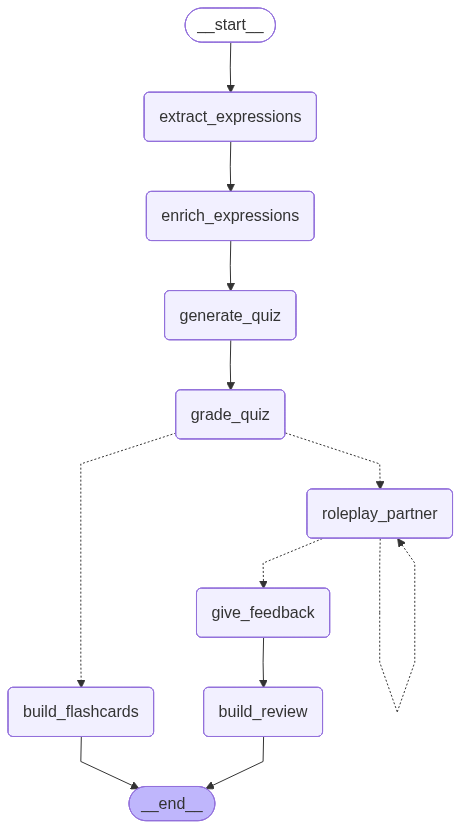

In [8]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_ascii())

## 7. 실행 데모 A — `practice_mode="roleplay"`

In [9]:
config_a = {"configurable": {"thread_id": "learner-001"}}

init_a: LearningState = {
    "native_language": "한국어",
    "target_language": "English",
    "transcript": SAMPLE_TRANSCRIPT,
    "key_expressions": [],
    "enriched_expressions": [],
    "quiz": [],
    "quiz_answers": ["I'll have", "make", "here"],   # 사용자의 퀴즈 답 (Q3 오답)
    "quiz_score": 0,
    "practice_mode": "roleplay",                     # ← 분기 입력
    "messages": [],
    "turn_count": 0,
    "max_turns": 3,
    "feedback": "",
    "review_list": [],
    "flashcards": [],
    "study_history": [],
    "stage": "start",
}
result = app.invoke(init_a, config_a)

# 출력용 정규화
R = {
    "expressions": result["enriched_expressions"],
    "quiz": result["quiz"],
    "answers": result["quiz_answers"],
    "score": result["quiz_score"],
    "mode": result["practice_mode"],
    "messages": [("human" if isinstance(m, HumanMessage) else "ai", m.content)
                 for m in result["messages"]],
    "feedback": result["feedback"],
    "review": result["review_list"],
}

print("=" * 60); print("① 표현 + 🔧 tool 보강"); print("=" * 60)
for e in R["expressions"]:
    print(f"- {e['expression']:<24} | {e['meaning']}")
    print(f"    synonyms: {', '.join(e['synonyms'])}")
    print(f"    example : {e['extra_examples'][0]}")
print()
print("=" * 60); print(f"② 퀴즈 채점: {R['score']}/{len(R['quiz'])}점"); print("=" * 60)
for i, q in enumerate(R["quiz"], 1):
    ok = R["answers"][i-1].strip().lower() == q["answer"].strip().lower()
    print(f"{'✅' if ok else '❌'} Q{i}. 정답={q['answer']} / 내 답={R['answers'][i-1]}")
print()
print("=" * 60); print(f"③ 연습 모드: {R['mode']} → roleplay 경로"); print("=" * 60)
for role, content in R["messages"]:
    print(f"{'🧑 학습자' if role=='human' else '🤖 파트너'}: {content}")
print()
print("=" * 60); print("④ 피드백"); print("=" * 60)
print(R["feedback"])
print()
print("=" * 60); print("⑤ 복습 리스트"); print("=" * 60)
for e in R["review"]:
    print(f"- {e['expression']:<24} | {e['review_after_days']}일 후 복습")

/var/folders/9v/k_94gjg116g30qm4phyc5pzr0000gn/T/ipykernel_98810/63180161.py:32: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


[web search fallback] What can I get for you today?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] I'll have...: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] Would you like it hot or iced?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] Could you make it less sweet?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] Is that for here or to go?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] Anything else?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] That's all.: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] That comes to...: Could not import ddgs python package. Please install 

## 8. 💾 메모리 확인 (SQLite)

`SqliteSaver` 덕분에 `thread_id="learner-001"` 의 상태가 **SQLite 파일에 저장**됩니다.
`get_state()` 로 누적된 학습 이력(`study_history`)을 꺼내 봅니다.
커널을 재시작한 뒤 같은 `thread_id` 로 `get_state()` 를 호출해도 이 이력이 그대로 남아 있습니다.

In [10]:
saved = app.get_state(config_a)
print("💾 SQLite에 저장된 학습 이력 (thread=learner-001):")
for h in saved.values["study_history"]:
    print("  •", h)

💾 SQLite에 저장된 학습 이력 (thread=learner-001):
  • 🔧 enriched 8 expressions
  • 📝 quiz score 0/3
  • 🔁 review scheduled: 8 expressions
  • 🔧 enriched 9 expressions
  • 📝 quiz score 0/3
  • 🔁 review scheduled: 9 expressions


## 9. 실행 데모 B — `practice_mode="flashcards"` (분기 확인)

같은 그래프에 **다른 사용자 입력**을 주면 Conditional Edge가 **다른 경로**로 흐릅니다.

In [11]:
config_b = {"configurable": {"thread_id": "learner-002"}}

init_b: LearningState = {
    "native_language": "한국어",
    "target_language": "English",
    "transcript": SAMPLE_TRANSCRIPT,
    "key_expressions": [],
    "enriched_expressions": [],
    "quiz": [],
    "quiz_answers": ["I'll have", "make", "to go"],  # 이번엔 모두 정답
    "quiz_score": 0,
    "practice_mode": "flashcards",                   # ← 다른 분기
    "messages": [],
    "turn_count": 0,
    "max_turns": 3,
    "feedback": "",
    "review_list": [],
    "flashcards": [],
    "study_history": [],
    "stage": "start",
}
result_b = app.invoke(init_b, config_b)

print(f"연습 모드: {result_b['practice_mode']} → flashcards 경로")
print(f"퀴즈 점수: {result_b['quiz_score']}/{len(result_b['quiz'])}")
print("-" * 60)
for i, c in enumerate(result_b["flashcards"], 1):
    print(f"[{i}] {c['front']}")
    print(f"     뜻 : {c['back']}")
    print(f"     예 : {c['example']}")

[web search fallback] What can I get for you today?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] I'll have...: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] Would you like it hot or iced?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] Could you make it less sweet?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] Is that for here or to go?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] Anything else?: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] That's all.: Could not import ddgs python package. Please install it with `pip install -U ddgs`.
[web search fallback] That comes to...: Could not import ddgs python package. Please install 

## 부록 A. 🚀 병렬 실행 (Send API) — 선택

표현이 많을 때 `enrich_expressions` 를 **표현별로 병렬 실행**하면 Tool 호출 지연을 줄일 수 있습니다.

In [12]:
from typing import TypedDict
try:
    from langgraph.types import Send
except ImportError:                       # 구버전 호환
    from langgraph.constants import Send


class FanState(TypedDict):
    expressions: list
    enriched: Annotated[list, operator.add]   # 병렬 결과를 리듀서로 취합


def dispatch(state: FanState):
    # 표현 하나당 enrich_one 태스크를 병렬로 fan-out
    return [Send("enrich_one", {"expr": e}) for e in state["expressions"]]


def enrich_one(payload: dict) -> dict:
    e = payload["expr"]
    d = dictionary_lookup.invoke({"expression": e})
    return {"enriched": [{"expression": e, "definition": d["definition"]}]}


fan = StateGraph(FanState)
fan.add_node("enrich_one", enrich_one)
fan.add_conditional_edges(START, dispatch, ["enrich_one"])
fan.add_edge("enrich_one", END)
fan_app = fan.compile()

out = fan_app.invoke({"expressions": [e["expression"] for e in MOCK_EXPRESSIONS],
                      "enriched": []})
print("병렬 보강 결과:", len(out["enriched"]), "개")
for e in sorted(out["enriched"], key=lambda x: x["expression"]):
    print(f" - {e['expression']:<24} | def: {e['definition']}")

병렬 보강 결과: 5 개
 - Anything else?           | def: asking if more is needed
 - Could you make it ...?   | def: politely request a change
 - I'll have ...            | def: used to place an order
 - for here or to go        | def: dine-in or takeout
 - that comes to ...        | def: stating the total price
